<a href="https://colab.research.google.com/github/rwlkunal03/EV_DYNAMIC_TARIFF/blob/main/EV_DYNAMIC_TARIFF_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
acn = pd.read_excel('/content/acndata_sessions.json.xlsx')

In [8]:
acn['connectionTime']   = pd.to_datetime(acn['connectionTime'],   utc=True, errors='coerce')
acn['disconnectTime']   = pd.to_datetime(acn['disconnectTime'],   utc=True, errors='coerce')
acn['doneChargingTime'] = pd.to_datetime(acn['doneChargingTime'], utc=True, errors='coerce')

In [9]:
acn = acn.dropna(subset=['kWhDelivered', 'connectionTime', 'disconnectTime'])

In [10]:
print('rows after cleaning:', len(acn))
acn[['connectionTime','disconnectTime','kWhDelivered','stationID']].head()

rows after cleaning: 14999


,connectionTime,disconnectTime,kWhDelivered,stationID
0,2018-04-25 11:08:04+00:00,2018-04-25 13:20:10+00:00,7.932,2-39-78-362
1,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,10.013,2-39-95-27
2,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,5.257,2-39-79-380
3,2018-04-25 14:37:06+00:00,2018-04-25 23:55:34+00:00,5.177,2-39-79-379
4,2018-04-25 14:40:34+00:00,2018-04-25 23:03:12+00:00,10.119,2-39-79-381


In [11]:
acn['session_hrs'] = (acn['disconnectTime'] - acn['connectionTime']).dt.total_seconds() / 3600

In [12]:
acn['charging_hrs'] = (acn['doneChargingTime'] - acn['connectionTime']).dt.total_seconds() / 3600

In [13]:
acn['idle_hrs'] = acn['session_hrs'] - acn['charging_hrs']

In [14]:
acn['util_rate'] = (acn['charging_hrs'] / acn['session_hrs']).clip(0, 1)

In [15]:
acn['hour']       = acn['connectionTime'].dt.hour
acn['dow']        = acn['connectionTime'].dt.dayofweek  # 0 = Monday
acn['is_weekend'] = acn['dow'].isin([5, 6]).astype(int)
acn['month']      = acn['connectionTime'].dt.month

In [16]:
acn['revenue_fixed'] = acn['kWhDelivered'] * 15

In [17]:
print('features created')
acn[['session_hrs','charging_hrs','util_rate','hour','dow','is_weekend','revenue_fixed']].describe()

features created


,session_hrs,charging_hrs,util_rate,hour,dow,is_weekend,revenue_fixed
count,14999.000000,14991.000000,14991.000000,14999.00000,14999.000000,14999.000000,14999.000000
mean,5.923631,3.236411,0.691463,13.15401,2.686712,0.186412,135.036986
std,6.459457,3.185251,0.325489,6.94637,1.838362,0.389452,105.837713
min,0.087500,-0.689444,0.000000,0.00000,0.000000,0.000000,7.515000
25%,2.025139,1.271806,0.387864,7.00000,1.000000,0.000000,60.127500
50%,4.764167,2.241667,0.815488,15.00000,3.000000,0.000000,111.525000
75%,8.729722,4.244444,0.998646,18.00000,4.000000,0.000000,198.060000
max,245.269167,104.428333,1.000000,23.00000,6.000000,1.000000,1040.595000


In [18]:
vol   = pd.read_csv('/content/volume.csv',    index_col='timestamp')
occ   = pd.read_csv('/content/occupancy.csv', index_col='timestamp')
dur   = pd.read_csv('/content/duration.csv',  index_col='timestamp')
price = pd.read_csv('/content/price.csv',     index_col='timestamp')
info  = pd.read_csv('/content/information.csv')
time_df = pd.read_csv('/content/time.csv')

In [19]:
time_df['datetime'] = pd.to_datetime(time_df[['year','month','day','hour','minute','second']])
datetimes = time_df['datetime'].values

In [20]:
vol.index   = datetimes
occ.index   = datetimes
dur.index   = datetimes
price.index = datetimes

In [21]:
print('vol shape:', vol.shape, '  -> 8640 time steps, 247 stations')
print('time range:', time_df['datetime'].iloc[0], 'to', time_df['datetime'].iloc[-1])
info.head(3)

vol shape: (8640, 247)   -> 8640 time steps, 247 stations
time range: 2022-06-19 00:00:00 to 2022-07-18 23:55:00


,num,grid,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,1,102,30,3,27,0.71,114.1030,22.54041,0,0
1,3,105,93,0,93,0.77,114.1208,22.55127,0,0
2,5,107,88,2,86,0.89,114.1304,22.54486,0,0


In [22]:
def melt_matrix(df, val_name):
    return df.reset_index().rename(columns={'index':'datetime'}).melt(
        id_vars='datetime', var_name='station_id', value_name=val_name
    )

In [23]:
vol_long   = melt_matrix(vol,   'volume')
occ_long   = melt_matrix(occ,   'occ')
dur_long   = melt_matrix(dur,   'dur')
price_long = melt_matrix(price, 'price_val')

In [24]:
urban = vol_long.copy()
urban['occ']       = occ_long['occ'].values
urban['dur']       = dur_long['dur'].values
urban['price_val'] = price_long['price_val'].values

In [25]:
info['grid'] = info['grid'].astype(str)
urban = urban.merge(info[['grid','count','fast_count','CBD']],
                    left_on='station_id', right_on='grid', how='left')

In [26]:
urban['datetime']   = pd.to_datetime(urban['datetime'])
urban['hour']       = urban['datetime'].dt.hour
urban['dow']        = urban['datetime'].dt.dayofweek
urban['is_weekend'] = urban['dow'].isin([5,6]).astype(int)

In [27]:
urban['util_rate'] = (urban['occ'] / urban['count']).clip(0, 1)

In [28]:
print('urban df shape:', urban.shape)
urban[['datetime','station_id','volume','occ','util_rate','CBD']].head()

urban df shape: (2134080, 14)


,datetime,station_id,volume,occ,util_rate,CBD
0,2022-06-19 00:00:00,102,2.858333,12,0.4,0
1,2022-06-19 00:05:00,102,4.375000,12,0.4,0
2,2022-06-19 00:10:00,102,4.375000,12,0.4,0
3,2022-06-19 00:15:00,102,4.375000,12,0.4,0
4,2022-06-19 00:20:00,102,4.375000,12,0.4,0


Text(0.5, 0.98, 'ACN Data — Demand Patterns')

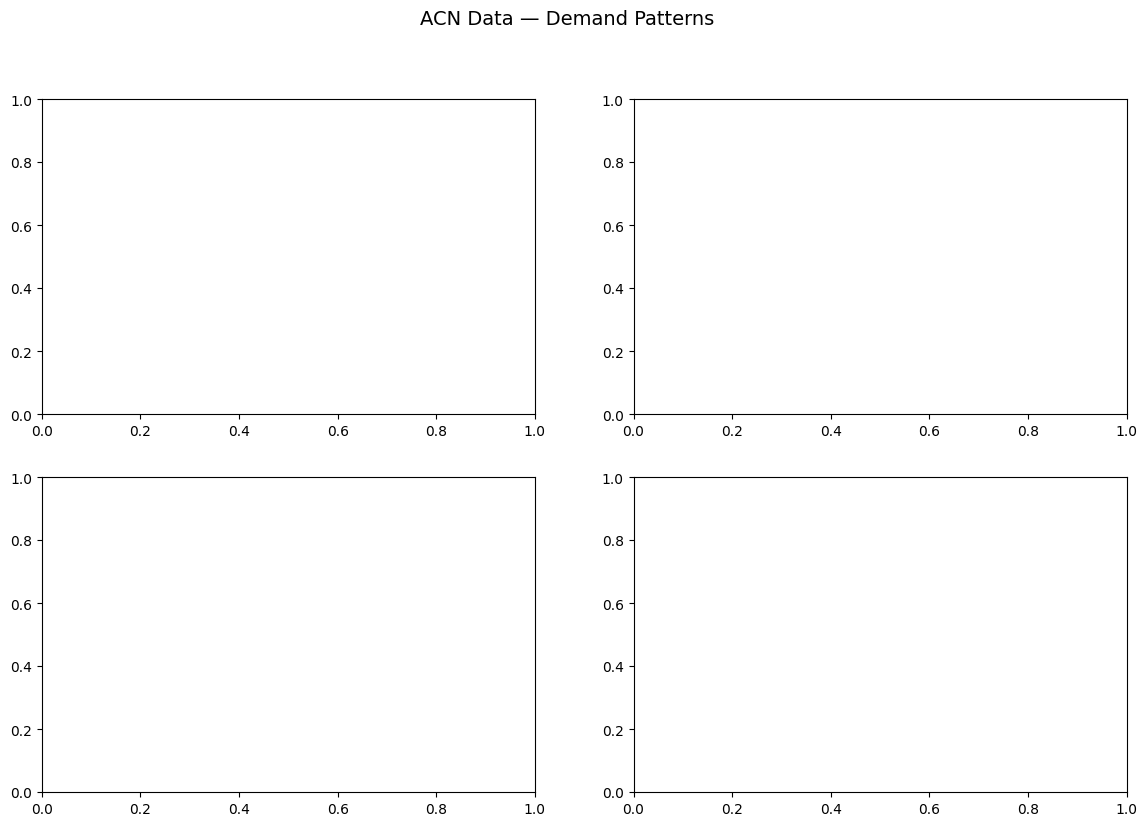

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('ACN Data — Demand Patterns', fontsize=14)

In [38]:
acn.groupby('hour').size().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Number of Sessions by Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Session Count')

Text(4.444444444444452, 0.5, 'Session Count')

In [40]:
acn.groupby('hour')['kWhDelivered'].mean().plot(kind='line', ax=axes[0,1], marker='o', color='darkorange')
axes[0,1].set_title('Avg kWh Delivered by Hour')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Avg kWh')


Text(596.2626262626262, 0.5, 'Avg kWh')

In [41]:
acn.groupby(['is_weekend','hour'])['kWhDelivered'].mean().unstack(0).plot(
    ax=axes[1,0], label=['Weekday','Weekend'])
axes[1,0].set_title('Weekday vs Weekend kWh')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].legend(['Weekday','Weekend'])

In [43]:
acn['util_rate'].plot.hist(bins=30, ax=axes[1,1], color='green', edgecolor='white')
axes[1,1].set_title('Charger Utilization Rate Distribution')
axes[1,1].set_xlabel('Utilization Rate')
axes[1,1].set_ylabel('Count')

Text(596.2626262626262, 0.5, 'Count')

In [44]:
plt.tight_layout()
plt.savefig('acn_eda.png', dpi=120)
plt.show()

<Figure size 640x480 with 0 Axes>

Text(0.5, 0.98, 'UrbanEV Data — Shenzhen Charging Patterns')

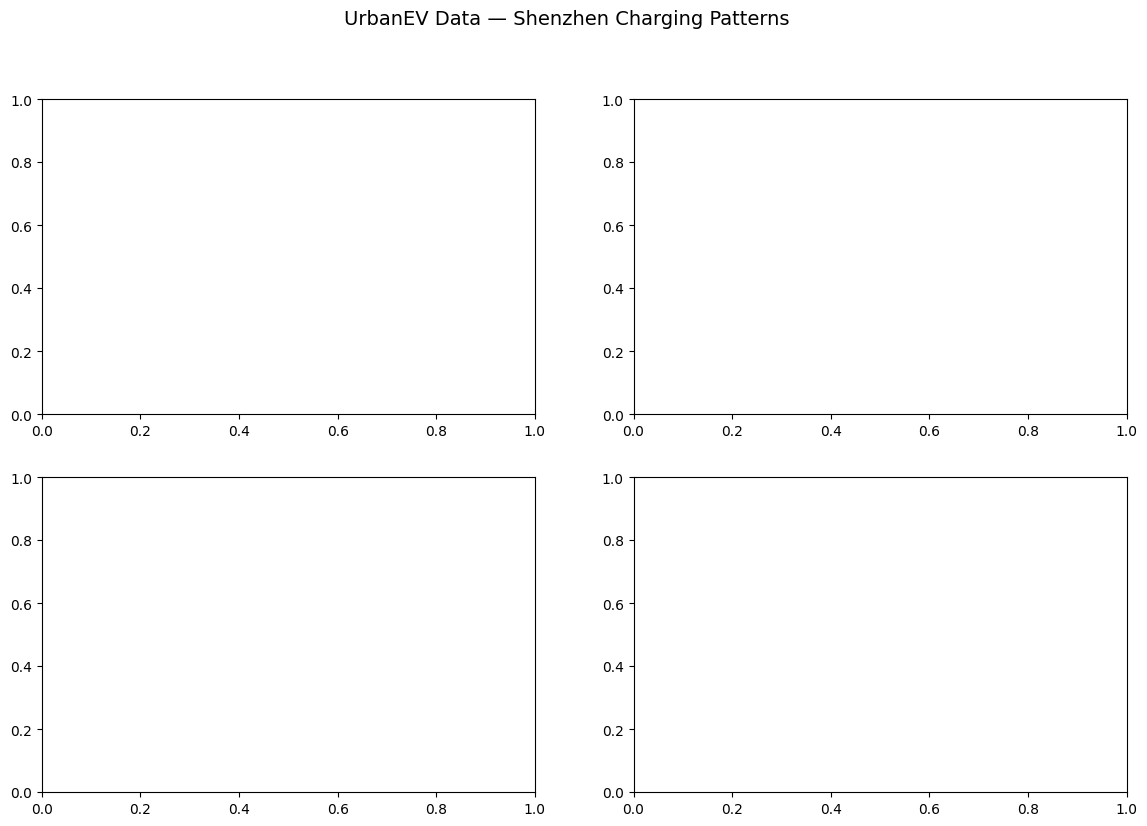

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('UrbanEV Data — Shenzhen Charging Patterns', fontsize=14)

In [46]:
urban.groupby('hour')['volume'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Avg Charging Volume by Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Avg Volume')

Text(4.444444444444452, 0.5, 'Avg Volume')

In [47]:
urban.groupby(['CBD','hour'])['volume'].mean().unstack(0).plot(ax=axes[0,1])
axes[0,1].set_title('CBD vs Non-CBD Volume by Hour')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].legend(['Non-CBD','CBD'])

In [48]:
sample = urban.sample(5000, random_state=1)
axes[1,0].scatter(sample['price_val'], sample['volume'], alpha=0.2, s=5, color='purple')
axes[1,0].set_title('Price vs Volume (Demand Elasticity)')
axes[1,0].set_xlabel('Price Multiplier')
axes[1,0].set_ylabel('Volume')

Text(4.444444444444452, 0.5, 'Volume')

In [49]:
urban.groupby('hour')['util_rate'].mean().plot(kind='line', ax=axes[1,1], marker='o', color='red')
axes[1,1].axhline(0.8, color='red', linestyle='--', label='Surge threshold (80%)')
axes[1,1].axhline(0.3, color='green', linestyle='--', label='Discount threshold (30%)')
axes[1,1].set_title('Avg Utilization Rate by Hour')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].legend()

In [50]:
plt.tight_layout()
plt.savefig('urbanev_eda.png', dpi=120)
plt.show()

<Figure size 640x480 with 0 Axes>

In [51]:
busy_stations = urban.groupby('station_id')['occ'].mean().nlargest(15).index.tolist()

In [52]:
heat_data = urban[urban['station_id'].isin(busy_stations)].pivot_table(
    values='util_rate', index='hour', columns='station_id', aggfunc='mean'
)

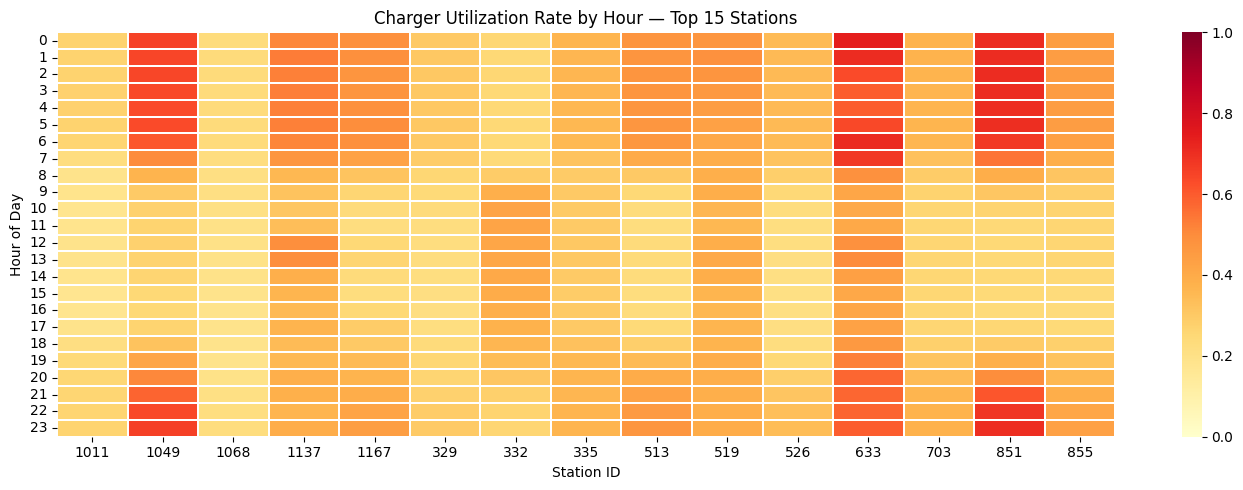

In [53]:
plt.figure(figsize=(14, 5))
sns.heatmap(heat_data, cmap='YlOrRd', linewidths=0.3, vmin=0, vmax=1)
plt.title('Charger Utilization Rate by Hour — Top 15 Stations')
plt.xlabel('Station ID')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig('heatmap_utilization.png', dpi=120)
plt.show()

In [54]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [55]:
sample_df = urban.sample(200000, random_state=42).dropna()

In [56]:
features = ['hour', 'dow', 'is_weekend', 'occ', 'dur', 'price_val', 'fast_count', 'CBD']
target   = 'volume'

In [57]:
X = sample_df[features]
y = sample_df[target]

In [58]:
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [59]:
print('train size:', len(X_train), '  test size:', len(X_test))

train size: 160000   test size: 40000


In [60]:
rf  = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb  = GradientBoostingRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

In [62]:
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [63]:
def evaluate(model, name):
    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    return {'Model': name, 'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)}

In [64]:
results = pd.DataFrame([
    evaluate(rf,  'Random Forest'),
    evaluate(gb,  'Gradient Boosting'),
    evaluate(xgb, 'XGBoost')
])

In [65]:
print(results.to_string(index=False))
results.to_csv('model_comparison.csv', index=False)

            Model    RMSE    MAE     R2
    Random Forest  8.9968 2.3679 0.9921
Gradient Boosting 26.1826 9.6749 0.9332
          XGBoost 10.3794 3.8073 0.9895


In [66]:
importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)

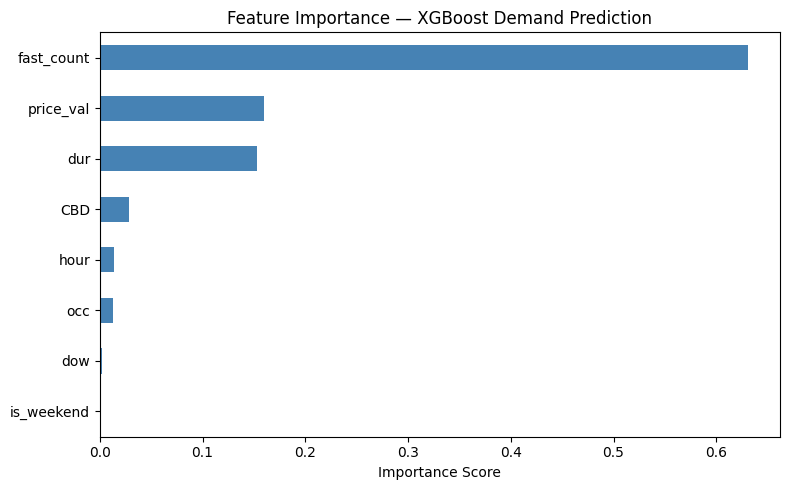

In [67]:
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — XGBoost Demand Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

In [68]:
def get_tariff(util):
    base = 15
    if util > 0.80:
        return round(base * 1.50, 2)
    elif util < 0.30:
        return round(base * 0.70, 2)
    else:
        factor = 0.70 + ((util - 0.30) / 0.50) * 0.80
        return round(base * factor, 2)

In [69]:
urban['dynamic_tariff']   = urban['util_rate'].apply(get_tariff)
urban['revenue_dynamic']  = urban['volume'] * urban['dynamic_tariff']
urban['revenue_fixed']    = urban['volume'] * 15

In [70]:
total_dynamic = urban['revenue_dynamic'].sum()
total_fixed   = urban['revenue_fixed'].sum()
gain_pct      = ((total_dynamic - total_fixed) / total_fixed) * 100

In [71]:
print(f'Fixed pricing total revenue:   {total_fixed:,.0f}')
print(f'Dynamic pricing total revenue: {total_dynamic:,.0f}')
print(f'Revenue gain: {gain_pct:.2f}%')

Fixed pricing total revenue:   1,174,121,129
Dynamic pricing total revenue: 1,143,997,964
Revenue gain: -2.57%


In [72]:
util_vals  = np.linspace(0, 1, 200)
tariff_vals = [get_tariff(u) for u in util_vals]

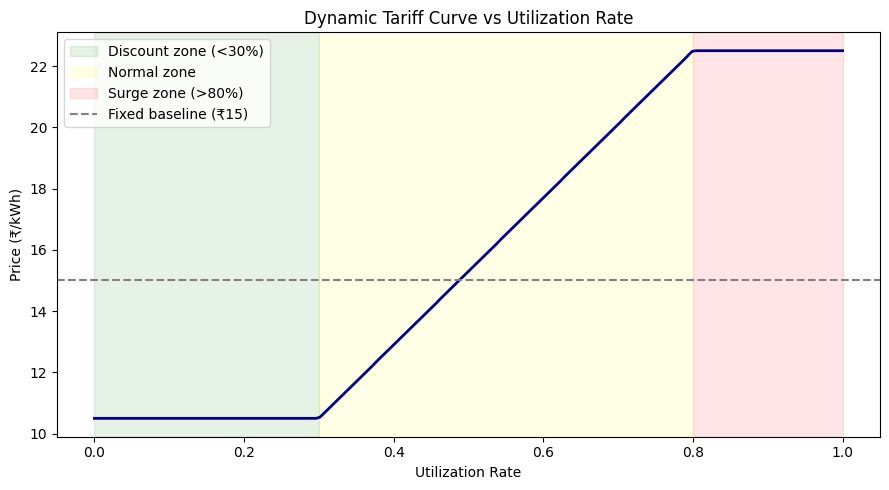

In [73]:
plt.figure(figsize=(9, 5))
plt.plot(util_vals, tariff_vals, color='darkblue', linewidth=2)
plt.axvspan(0,    0.30, alpha=0.1, color='green',  label='Discount zone (<30%)')
plt.axvspan(0.30, 0.80, alpha=0.1, color='yellow', label='Normal zone')
plt.axvspan(0.80, 1.00, alpha=0.1, color='red',    label='Surge zone (>80%)')
plt.axhline(15, linestyle='--', color='gray', label='Fixed baseline (₹15)')
plt.title('Dynamic Tariff Curve vs Utilization Rate')
plt.xlabel('Utilization Rate')
plt.ylabel('Price (₹/kWh)')
plt.legend()
plt.tight_layout()
plt.savefig('tariff_curve.png', dpi=120)
plt.show()

In [74]:
offpeak_mask = urban['util_rate'] < 0.30
surge_mask   = urban['util_rate'] > 0.80

In [75]:
print('Off-peak sessions (util < 30%):', offpeak_mask.sum())
print('Avg discount offered:', round(urban.loc[offpeak_mask,'dynamic_tariff'].mean(), 2), '₹/kWh')
print()
print('Surge sessions (util > 80%):', surge_mask.sum())
print('Avg surge price:', round(urban.loc[surge_mask,'dynamic_tariff'].mean(), 2), '₹/kWh')

Off-peak sessions (util < 30%): 1298676
Avg discount offered: 10.5 ₹/kWh

Surge sessions (util > 80%): 21874
Avg surge price: 22.5 ₹/kWh


In [76]:
util_before = urban['util_rate'].mean()
print(f'\nAvg utilization rate (before dynamic pricing): {util_before:.3f}')


Avg utilization rate (before dynamic pricing): 0.280


In [77]:
urban['date'] = pd.to_datetime(urban['datetime']).dt.date

In [78]:
daily = urban.groupby('date').agg(
    revenue_dynamic = ('revenue_dynamic', 'sum'),
    revenue_fixed   = ('revenue_fixed',   'sum'),
    avg_util        = ('util_rate',        'mean'),
    total_volume    = ('volume',           'sum')
).reset_index()

In [79]:
daily['gain_pct'] = ((daily['revenue_dynamic'] - daily['revenue_fixed']) / daily['revenue_fixed']) * 100

In [80]:
daily['pricing_efficiency'] = daily['revenue_dynamic'] / daily['total_volume']

In [81]:
print(daily[['date','gain_pct','avg_util','pricing_efficiency']].head(10).to_string(index=False))

      date  gain_pct  avg_util  pricing_efficiency
2022-06-19 -4.343175  0.276808           14.348524
2022-06-20 -6.127760  0.270900           14.080836
2022-06-21 -4.143891  0.270110           14.378416
2022-06-22 -4.092476  0.271326           14.386129
2022-06-23 -4.243538  0.271452           14.363469
2022-06-24 -2.501857  0.274935           14.624721
2022-06-25 -1.810837  0.285465           14.728374
2022-06-26 -4.959756  0.277958           14.256037
2022-06-27 -4.764108  0.274906           14.285384
2022-06-28 -2.281635  0.283978           14.657755


Text(0.5, 0.98, 'Monitoring Agent — Daily Metrics Over Time')

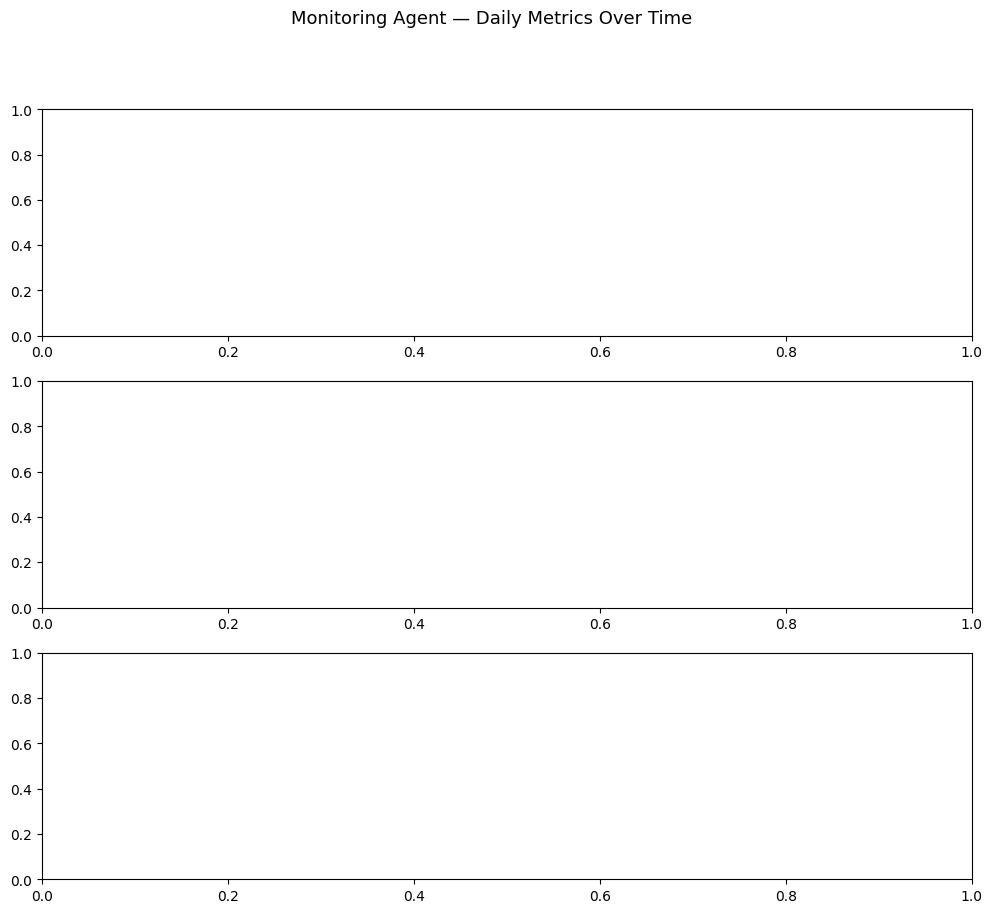

In [82]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('Monitoring Agent — Daily Metrics Over Time', fontsize=13)

In [83]:
axes[0].plot(daily['date'], daily['pricing_efficiency'], color='steelblue', marker='o', markersize=3)
axes[0].set_title('Pricing Efficiency (Revenue per Unit Volume)')
axes[0].set_ylabel('₹ per unit')

Text(4.444444444444466, 0.5, '₹ per unit')

In [84]:
axes[1].plot(daily['date'], daily['avg_util'], color='darkorange', marker='o', markersize=3)
axes[1].axhline(0.8, linestyle='--', color='red',   label='Surge threshold')
axes[1].axhline(0.3, linestyle='--', color='green', label='Discount threshold')
axes[1].set_title('Average Utilization Rate')
axes[1].set_ylabel('Utilization Rate')
axes[1].legend()

In [85]:
axes[2].bar(daily['date'], daily['gain_pct'], color='green')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Revenue Gain % vs Fixed Baseline')
axes[2].set_ylabel('Gain %')

Text(4.444444444444466, 0.5, 'Gain %')

In [86]:
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

In [87]:
plt.tight_layout()
plt.savefig('monitoring_metrics.png', dpi=120)
plt.show()

<Figure size 640x480 with 0 Axes>

In [88]:
urban_sorted = urban.sort_values(['station_id','datetime'])
urban_sorted['price_change'] = urban_sorted.groupby('station_id')['dynamic_tariff'].diff()
urban_sorted['volume_change'] = urban_sorted.groupby('station_id')['volume'].diff()

In [89]:
crr_data = urban_sorted[['price_change','volume_change']].dropna()
crr = crr_data.corr().iloc[0,1]

In [90]:
print(f'Customer Response Rate (price vs volume correlation): {crr:.4f}')
print('(negative value means volume drops when price rises — expected)')

Customer Response Rate (price vs volume correlation): 0.2812
(negative value means volume drops when price rises — expected)


In [91]:
acn['dynamic_tariff']  = acn['util_rate'].apply(get_tariff)
acn['revenue_dynamic'] = acn['kWhDelivered'] * acn['dynamic_tariff']

In [92]:
acn_gain = ((acn['revenue_dynamic'].sum() - acn['revenue_fixed'].sum())
            / acn['revenue_fixed'].sum()) * 100

In [93]:
print('ACN dataset revenue gain from dynamic pricing:', round(acn_gain, 2), '%')

ACN dataset revenue gain from dynamic pricing: 26.18 %


In [94]:
hourly_rev = acn.groupby('hour').agg(
    fixed=('revenue_fixed','sum'),
    dynamic=('revenue_dynamic','sum')
)

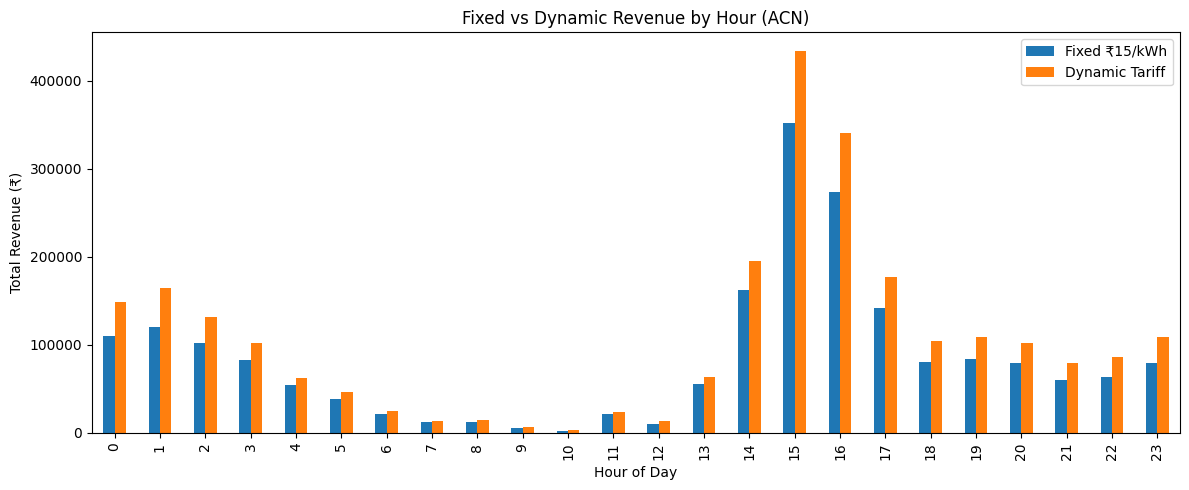

In [95]:
hourly_rev.plot(kind='bar', figsize=(12,5), title='Fixed vs Dynamic Revenue by Hour (ACN)')
plt.xlabel('Hour of Day')
plt.ylabel('Total Revenue (₹)')
plt.legend(['Fixed ₹15/kWh','Dynamic Tariff'])
plt.tight_layout()
plt.savefig('acn_revenue_comparison.png', dpi=120)
plt.show()

In [96]:
acn[['sessionID','connectionTime','kWhDelivered','session_hrs',
     'util_rate','hour','is_weekend','revenue_fixed','dynamic_tariff','revenue_dynamic']].to_csv(
    'acn_processed.csv', index=False
)

In [97]:
urban.sample(50000, random_state=1)[[
    'datetime','station_id','volume','util_rate',
    'dynamic_tariff','revenue_dynamic','revenue_fixed','CBD'
]].to_csv('tariff_outcomes.csv', index=False)

In [98]:
daily.to_csv('monitoring_daily.csv', index=False)

In [99]:
print('all files saved:')
print('  acn_processed.csv')
print('  tariff_outcomes.csv')
print('  monitoring_daily.csv')
print('  model_comparison.csv')

all files saved:
  acn_processed.csv
  tariff_outcomes.csv
  monitoring_daily.csv
  model_comparison.csv


In [100]:
print('=== PROJECT SUMMARY ===')
print()
print('--- Datasets ---')
print(f'ACN sessions used:         {len(acn):,}')
print(f'UrbanEV time steps:        {len(vol):,}')
print(f'UrbanEV stations:          {vol.shape[1]}')
print()
print('--- Demand Prediction (XGBoost) ---')
best = results[results['Model']=='XGBoost'].iloc[0]
print(f'RMSE:  {best["RMSE"]}')
print(f'MAE:   {best["MAE"]}')
print(f'R2:    {best["R2"]}')
print()
print('--- Tariff Pricing Agent ---')
print(f'UrbanEV Revenue Gain:  {gain_pct:.2f}%')
print(f'ACN Revenue Gain:      {acn_gain:.2f}%')
print(f'Off-peak sessions:     {offpeak_mask.sum():,}')
print(f'Surge sessions:        {surge_mask.sum():,}')
print()
print('--- Monitoring Agent ---')
print(f'Customer Response Rate:         {crr:.4f}')
print(f'Avg Pricing Efficiency (₹/vol): {daily["pricing_efficiency"].mean():.2f}')

=== PROJECT SUMMARY ===

--- Datasets ---
ACN sessions used:         14,999
UrbanEV time steps:        8,640
UrbanEV stations:          247

--- Demand Prediction (XGBoost) ---
RMSE:  10.3794
MAE:   3.8073
R2:    0.9895

--- Tariff Pricing Agent ---
UrbanEV Revenue Gain:  -2.57%
ACN Revenue Gain:      26.18%
Off-peak sessions:     1,298,676
Surge sessions:        21,874

--- Monitoring Agent ---
Customer Response Rate:         0.2812
Avg Pricing Efficiency (₹/vol): 14.60
